# SMHI Individual Parameter Download & Exploration

## Purpose

This notebook downloads **each SMHI parameter separately** from all available stations, then analyzes the data to find **common ground** - stations that have multiple parameters we need.

### Why This Approach?

Previous attempts to download merged multi-parameter data resulted in sparse datasets because:
- Different stations measure different parameters
- Merging creates many NULL values
- Hard to identify which stations have good multi-parameter coverage

**Solution**: Download each parameter individually, then analyze to find overlap.

### What This Notebook Does

1. **Part 1**: Download all ~40 SMHI parameters individually to `data/raw/parameters/`
2. **Part 2**: Analyze each parameter's coverage (stations, dates, records)
3. **Part 3**: Find common stations across key parameters
4. **Part 4**: Recommend optimal station/parameter combinations

### Output Files

Each parameter will be saved as:
```
data/raw/parameters/
  ├── param_01_temp_1min.csv
  ├── param_02_temp_mean.csv
  ├── param_08_snow_depth.csv
  └── ... (one file per parameter)
```

---
# Part 1: Setup and Parameter Definitions

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import os
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Optional, Tuple
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [28]:
# Configuration
BASE_URL = "https://opendata-download-metobs.smhi.se/api/version/1.0"
OUTPUT_DIR = Path('../data/raw/parameters')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

START_DATE = "2015-01-01"
END_DATE = "2025-12-31"

# Delay between API requests (be respectful to the API)
API_DELAY = 0.15  # seconds

print(f"Output directory: {OUTPUT_DIR.absolute()}")
print(f"Date range: {START_DATE} to {END_DATE}")

Output directory: /scratch/gdemil24/RISE/nordic-snow-monitoring/notebooks/../data/raw/parameters
Date range: 2015-01-01 to 2025-12-31


In [2]:
# Complete list of SMHI parameters
# Source: https://opendata.smhi.se/apidocs/metobs/parameters.html

SMHI_PARAMETERS = {
    # Temperature
    1: {'name': 'temp_1min', 'desc': 'Air temperature (1-min)', 'unit': '°C', 'agg': 'mean'},
    2: {'name': 'temp_mean', 'desc': 'Air temperature (daily mean)', 'unit': '°C', 'agg': 'mean'},
    19: {'name': 'temp_min', 'desc': 'Air temperature (daily min)', 'unit': '°C', 'agg': 'min'},
    20: {'name': 'temp_max', 'desc': 'Air temperature (daily max)', 'unit': '°C', 'agg': 'max'},
    39: {'name': 'dew_point', 'desc': 'Dew point temperature', 'unit': '°C', 'agg': 'mean'},
    
    # Precipitation
    5: {'name': 'precip_sum', 'desc': 'Precipitation (daily sum)', 'unit': 'mm', 'agg': 'sum'},
    6: {'name': 'precip_6h', 'desc': 'Precipitation (6-hourly)', 'unit': 'mm', 'agg': 'sum'},
    7: {'name': 'precip_15min', 'desc': 'Precipitation (15-min)', 'unit': 'mm', 'agg': 'sum'},
    14: {'name': 'precip_hourly', 'desc': 'Precipitation (hourly)', 'unit': 'mm', 'agg': 'sum'},
    17: {'name': 'precip_2x_daily', 'desc': 'Precipitation (2x daily)', 'unit': 'mm', 'agg': 'sum'},
    
    # Snow
    8: {'name': 'snow_depth', 'desc': 'Snow depth (daily)', 'unit': 'm', 'agg': 'last'},
    23: {'name': 'snow_type', 'desc': 'Snow type code', 'unit': 'code', 'agg': 'last'},
    
    # Wind
    3: {'name': 'wind_dir', 'desc': 'Wind direction', 'unit': '°', 'agg': 'mean'},
    4: {'name': 'wind_speed', 'desc': 'Wind speed (10-min mean)', 'unit': 'm/s', 'agg': 'mean'},
    21: {'name': 'wind_gust', 'desc': 'Wind gust speed', 'unit': 'm/s', 'agg': 'max'},
    25: {'name': 'wind_speed_max', 'desc': 'Wind speed (daily max)', 'unit': 'm/s', 'agg': 'max'},
    
    # Pressure
    9: {'name': 'pressure_sea', 'desc': 'Sea-level pressure', 'unit': 'hPa', 'agg': 'mean'},
    10: {'name': 'sunshine', 'desc': 'Sunshine duration', 'unit': 's', 'agg': 'sum'},
    
    # Radiation
    11: {'name': 'global_irrad', 'desc': 'Global irradiance', 'unit': 'W/m²', 'agg': 'mean'},
    12: {'name': 'longwave_irrad', 'desc': 'Longwave irradiance', 'unit': 'W/m²', 'agg': 'mean'},
    
    # Humidity & Visibility
    13: {'name': 'visibility', 'desc': 'Visibility', 'unit': 'm', 'agg': 'mean'},
    15: {'name': 'precip_intensity', 'desc': 'Precipitation intensity', 'unit': 'mm/h', 'agg': 'mean'},
    16: {'name': 'cloud_cover', 'desc': 'Total cloud cover', 'unit': '%', 'agg': 'mean'},
    28: {'name': 'cloud_base', 'desc': 'Cloud base height (lowest)', 'unit': 'm', 'agg': 'mean'},
    29: {'name': 'humidity', 'desc': 'Relative humidity', 'unit': '%', 'agg': 'mean'},
    
    # Ground & Surface
    22: {'name': 'precip_type', 'desc': 'Precipitation type code', 'unit': 'code', 'agg': 'last'},
    24: {'name': 'snow_cover', 'desc': 'Snow cover presence', 'unit': 'code', 'agg': 'last'},
    26: {'name': 'temp_min_grass', 'desc': 'Min temperature at grass', 'unit': '°C', 'agg': 'min'},
    27: {'name': 'temp_min_bare', 'desc': 'Min temperature (bare ground)', 'unit': '°C', 'agg': 'min'},
    
    # Additional
    30: {'name': 'cloud_base_2', 'desc': 'Cloud base height (2nd layer)', 'unit': 'm', 'agg': 'mean'},
    31: {'name': 'cloud_base_3', 'desc': 'Cloud base height (3rd layer)', 'unit': 'm', 'agg': 'mean'},
    32: {'name': 'cloud_base_4', 'desc': 'Cloud base height (4th layer)', 'unit': 'm', 'agg': 'mean'},
    33: {'name': 'cloud_amount_1', 'desc': 'Cloud amount (1st layer)', 'unit': 'code', 'agg': 'mean'},
    34: {'name': 'cloud_amount_2', 'desc': 'Cloud amount (2nd layer)', 'unit': 'code', 'agg': 'mean'},
    35: {'name': 'cloud_amount_3', 'desc': 'Cloud amount (3rd layer)', 'unit': 'code', 'agg': 'mean'},
    36: {'name': 'cloud_amount_4', 'desc': 'Cloud amount (4th layer)', 'unit': 'code', 'agg': 'mean'},
    37: {'name': 'weather_wawa', 'desc': 'Present weather (WaWa)', 'unit': 'code', 'agg': 'last'},
    38: {'name': 'thunder', 'desc': 'Thunder indicator', 'unit': 'code', 'agg': 'max'},
    40: {'name': 'ground_state', 'desc': 'Ground state code', 'unit': 'code', 'agg': 'last'},
}

# Priority parameters for snow monitoring (most important first)
PRIORITY_PARAMS = [8, 2, 19, 20, 5, 4, 9, 29, 39, 16, 40, 10, 21]

print(f"Total parameters defined: {len(SMHI_PARAMETERS)}")
print(f"\nParameters:")
for pid, info in sorted(SMHI_PARAMETERS.items()):
    print(f"  {pid:>3}: {info['name']:<20} - {info['desc']} ({info['unit']})")

Total parameters defined: 39

Parameters:
    1: temp_1min            - Air temperature (1-min) (°C)
    2: temp_mean            - Air temperature (daily mean) (°C)
    3: wind_dir             - Wind direction (°)
    4: wind_speed           - Wind speed (10-min mean) (m/s)
    5: precip_sum           - Precipitation (daily sum) (mm)
    6: precip_6h            - Precipitation (6-hourly) (mm)
    7: precip_15min         - Precipitation (15-min) (mm)
    8: snow_depth           - Snow depth (daily) (m)
    9: pressure_sea         - Sea-level pressure (hPa)
   10: sunshine             - Sunshine duration (s)
   11: global_irrad         - Global irradiance (W/m²)
   12: longwave_irrad       - Longwave irradiance (W/m²)
   13: visibility           - Visibility (m)
   14: precip_hourly        - Precipitation (hourly) (mm)
   15: precip_intensity     - Precipitation intensity (mm/h)
   16: cloud_cover          - Total cloud cover (%)
   17: precip_2x_daily      - Precipitation (2x daily) (mm

---
# Part 2: Download Functions

In [3]:
def get_stations_for_parameter(param_id: int) -> List[Dict]:
    """
    Get all stations that have data for a specific parameter.
    
    Returns list of station dictionaries with id, name, lat, lon, etc.
    """
    url = f"{BASE_URL}/parameter/{param_id}.json"
    
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code != 200:
            print(f"  Warning: Failed to get stations (HTTP {resp.status_code})")
            return []
        
        data = resp.json()
        stations = []
        
        for station in data.get('station', []):
            stations.append({
                'station_id': station.get('id'),
                'station_name': station.get('name', f"Station_{station.get('id')}"),
                'latitude': station.get('latitude'),
                'longitude': station.get('longitude'),
                'elevation': station.get('height', 0),
                'active': station.get('active', False),
            })
        
        return stations
    
    except Exception as e:
        print(f"  Error: {e}")
        return []

In [4]:
def download_station_data(station_id: int, param_id: int, 
                          start_date: str, end_date: str) -> Optional[pd.DataFrame]:
    """
    Download data for a specific station and parameter.
    
    Returns DataFrame with columns: date, time, value
    """
    url = f"{BASE_URL}/parameter/{param_id}/station/{station_id}/period/corrected-archive/data.csv"
    
    try:
        resp = requests.get(url, timeout=60)
        if resp.status_code != 200:
            return None
        
        content = resp.text
        lines = content.split('\n')
        
        # Find header line (starts with 'Datum')
        data_start = None
        for i, line in enumerate(lines):
            if line.startswith('Datum'):
                data_start = i
                break
        
        if data_start is None:
            return None
        
        # Parse data lines
        records = []
        for line in lines[data_start + 1:]:
            if line.strip():
                parts = line.split(';')
                if len(parts) >= 3:
                    date_str = parts[0].strip()
                    time_str = parts[1].strip() if len(parts) > 1 else "00:00:00"
                    value_str = parts[2].strip()
                    
                    # Validate date format
                    if date_str and len(date_str) == 10 and date_str[4] == '-':
                        try:
                            value = float(value_str) if value_str else None
                            if value is not None:
                                records.append({
                                    'date': date_str,
                                    'time': time_str,
                                    'value': value
                                })
                        except ValueError:
                            continue
        
        if not records:
            return None
        
        df = pd.DataFrame(records)
        df['date'] = pd.to_datetime(df['date'])
        
        # Filter by date range
        start_dt = pd.to_datetime(start_date)
        end_dt = pd.to_datetime(end_date)
        df = df[(df['date'] >= start_dt) & (df['date'] <= end_dt)]
        
        return df if len(df) > 0 else None
    
    except Exception as e:
        return None

In [5]:
def aggregate_to_daily(df: pd.DataFrame, method: str = 'mean') -> pd.DataFrame:
    """
    Aggregate sub-daily data to daily values.
    """
    if method == 'mean':
        daily = df.groupby('date')['value'].mean().reset_index()
    elif method == 'sum':
        daily = df.groupby('date')['value'].sum().reset_index()
    elif method == 'max':
        daily = df.groupby('date')['value'].max().reset_index()
    elif method == 'min':
        daily = df.groupby('date')['value'].min().reset_index()
    elif method == 'last':
        daily = df.groupby('date')['value'].last().reset_index()
    else:
        daily = df.groupby('date')['value'].mean().reset_index()
    return daily

In [6]:
def download_parameter(param_id: int, param_info: Dict, 
                       start_date: str, end_date: str,
                       output_dir: Path, delay: float = 0.15) -> pd.DataFrame:
    """
    Download all data for a single parameter from all stations.
    
    Saves to CSV and returns the DataFrame.
    """
    param_name = param_info['name']
    agg_method = param_info['agg']
    
    print(f"\n{'='*70}")
    print(f"DOWNLOADING: Parameter {param_id} - {param_name}")
    print(f"Description: {param_info['desc']}")
    print(f"{'='*70}")
    
    # Get all stations for this parameter
    print("\nQuerying available stations...")
    stations = get_stations_for_parameter(param_id)
    print(f"Found {len(stations)} stations with {param_name} data")
    
    if not stations:
        print("No stations found, skipping...")
        return pd.DataFrame()
    
    # Download from each station
    all_data = []
    successful = 0
    
    for i, station in enumerate(stations):
        station_id = station['station_id']
        station_name = station['station_name']
        
        # Progress indicator every 50 stations
        if (i + 1) % 50 == 0 or i == 0:
            print(f"  Progress: {i+1}/{len(stations)} stations...")
        
        df = download_station_data(station_id, param_id, start_date, end_date)
        
        if df is not None and len(df) > 0:
            # Aggregate to daily
            daily_df = aggregate_to_daily(df, agg_method)
            
            # Add station info
            daily_df['station_id'] = station_id
            daily_df['station_name'] = station_name
            daily_df['latitude'] = station['latitude']
            daily_df['longitude'] = station['longitude']
            daily_df['elevation'] = station['elevation']
            
            all_data.append(daily_df)
            successful += 1
        
        time.sleep(delay)
    
    if not all_data:
        print(f"\nNo data retrieved for {param_name}")
        return pd.DataFrame()
    
    # Combine all stations
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Rename value column to parameter name
    combined_df = combined_df.rename(columns={'value': param_name})
    
    # Reorder columns
    col_order = ['date', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation', param_name]
    combined_df = combined_df[col_order]
    combined_df = combined_df.sort_values(['station_name', 'date'])
    
    # Save to CSV
    output_file = output_dir / f"param_{param_id:02d}_{param_name}.csv"
    combined_df.to_csv(output_file, index=False)
    
    # Print summary
    print(f"\n  Stations with data: {successful}/{len(stations)}")
    print(f"  Total records: {len(combined_df):,}")
    print(f"  Date range: {combined_df['date'].min().date()} to {combined_df['date'].max().date()}")
    print(f"  Saved to: {output_file}")
    
    return combined_df

---
# Part 3: Download All Parameters

This will download each parameter one by one. The download may take some time (1-2 hours for all parameters). You can interrupt and resume later - files already downloaded will be skipped.

**Note**: Run this cell to start downloading. Progress will be printed for each parameter.

In [9]:
# Check which parameters are already downloaded
existing_files = list(OUTPUT_DIR.glob('param_*.csv'))
existing_params = set()

for f in existing_files:
    # Extract param_id from filename like "param_08_snow_depth.csv"
    try:
        param_id = int(f.stem.split('_')[1])
        existing_params.add(param_id)
    except:
        pass

print(f"Already downloaded: {len(existing_params)} parameters")
print(f"Remaining to download: {len(SMHI_PARAMETERS) - len(existing_params)} parameters")

if existing_params:
    print(f"\nExisting files:")
    for f in sorted(existing_files):
        size_mb = f.stat().st_size / 1024**2
        print(f"  {f.name}: {size_mb:.2f} MB")

Already downloaded: 32 parameters
Remaining to download: 7 parameters

Existing files:
  param_01_temp_1min.csv: 64.93 MB
  param_03_wind_dir.csv: 44.54 MB
  param_04_wind_speed.csv: 45.36 MB
  param_06_precip_6h.csv: 39.37 MB
  param_07_precip_15min.csv: 31.66 MB
  param_08_snow_depth.csv: 85.47 MB
  param_09_pressure_sea.csv: 30.26 MB
  param_10_sunshine.csv: 4.26 MB
  param_11_global_irrad.csv: 4.38 MB
  param_12_longwave_irrad.csv: 41.10 MB
  param_13_visibility.csv: 39.97 MB
  param_14_precip_hourly.csv: 27.84 MB
  param_15_precip_intensity.csv: 0.26 MB
  param_16_cloud_cover.csv: 25.82 MB
  param_21_wind_gust.csv: 32.73 MB
  param_24_snow_cover.csv: 1.52 MB
  param_25_wind_speed_max.csv: 29.19 MB
  param_26_temp_min_grass.csv: 49.18 MB
  param_27_temp_min_bare.csv: 49.15 MB
  param_28_cloud_base.csv: 25.11 MB
  param_29_humidity.csv: 25.55 MB
  param_30_cloud_base_2.csv: 20.55 MB
  param_31_cloud_base_3.csv: 22.34 MB
  param_32_cloud_base_4.csv: 13.45 MB
  param_33_cloud_amount_1

In [9]:
# Download all parameters (skip existing)
# Start with priority parameters first, then the rest

download_order = PRIORITY_PARAMS + [p for p in SMHI_PARAMETERS.keys() if p not in PRIORITY_PARAMS]

download_results = {}
start_time = datetime.now()

print(f"Starting download at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Parameters to process: {len(download_order)}")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"\n" + "="*70)

for i, param_id in enumerate(download_order):
    if param_id not in SMHI_PARAMETERS:
        continue
    
    param_info = SMHI_PARAMETERS[param_id]
    
    # Check if already downloaded
    if param_id in existing_params:
        print(f"\n[{i+1}/{len(download_order)}] Skipping {param_info['name']} (already exists)")
        download_results[param_id] = 'skipped'
        continue
    
    print(f"\n[{i+1}/{len(download_order)}] Processing...")
    
    try:
        df = download_parameter(
            param_id=param_id,
            param_info=param_info,
            start_date=START_DATE,
            end_date=END_DATE,
            output_dir=OUTPUT_DIR,
            delay=API_DELAY
        )
        
        if len(df) > 0:
            download_results[param_id] = len(df)
        else:
            download_results[param_id] = 0
            
    except Exception as e:
        print(f"  ERROR: {e}")
        download_results[param_id] = 'error'

end_time = datetime.now()
duration = end_time - start_time

print(f"\n" + "="*70)
print(f"DOWNLOAD COMPLETE")
print(f"="*70)
print(f"Duration: {duration}")
print(f"Results: {len([v for v in download_results.values() if isinstance(v, int) and v > 0])} parameters with data")

Starting download at 2026-01-26 11:57:45
Parameters to process: 39
Date range: 2015-01-01 to 2025-12-31


[1/39] Processing...

DOWNLOADING: Parameter 8 - snow_depth
Description: Snow depth (daily)

Querying available stations...
Found 1896 stations with snow_depth data
  Progress: 1/1896 stations...
  Progress: 50/1896 stations...
  Progress: 100/1896 stations...
  Progress: 150/1896 stations...
  Progress: 200/1896 stations...
  Progress: 250/1896 stations...
  Progress: 300/1896 stations...
  Progress: 350/1896 stations...
  Progress: 400/1896 stations...
  Progress: 450/1896 stations...
  Progress: 500/1896 stations...
  Progress: 550/1896 stations...
  Progress: 600/1896 stations...
  Progress: 650/1896 stations...
  Progress: 700/1896 stations...
  Progress: 750/1896 stations...
  Progress: 800/1896 stations...
  Progress: 850/1896 stations...
  Progress: 900/1896 stations...
  Progress: 950/1896 stations...
  Progress: 1000/1896 stations...
  Progress: 1050/1896 stations...
  Pr

---
# Part 4: Explore Downloaded Data

Now let's analyze all downloaded parameters to understand coverage and find common stations.

In [10]:
# Load and analyze all downloaded parameter files
print("=" * 100)
print("ANALYZING DOWNLOADED PARAMETERS")
print("=" * 100)

param_files = sorted(OUTPUT_DIR.glob('param_*.csv'))
print(f"\nFound {len(param_files)} parameter files")

# Analyze each parameter
param_analysis = []

for f in param_files:
    # Extract param info from filename
    parts = f.stem.split('_')
    param_id = int(parts[1])
    param_name = '_'.join(parts[2:])
    
    # Load data
    df = pd.read_csv(f, parse_dates=['date'])
    
    # Calculate stats
    value_col = [c for c in df.columns if c not in ['date', 'station_id', 'station_name', 'latitude', 'longitude', 'elevation']][0]
    
    stats = {
        'param_id': param_id,
        'param_name': param_name,
        'file_size_mb': f.stat().st_size / 1024**2,
        'total_records': len(df),
        'unique_stations': df['station_id'].nunique(),
        'date_min': df['date'].min(),
        'date_max': df['date'].max(),
        'days_span': (df['date'].max() - df['date'].min()).days,
        'value_mean': df[value_col].mean(),
        'value_std': df[value_col].std(),
        'value_min': df[value_col].min(),
        'value_max': df[value_col].max(),
        'null_count': df[value_col].isna().sum(),
        'stations': set(df['station_id'].unique()),
    }
    param_analysis.append(stats)
    
    print(f"  {param_id:>2}: {param_name:<20} - {stats['total_records']:>10,} records, {stats['unique_stations']:>4} stations")

# Create summary DataFrame
analysis_df = pd.DataFrame(param_analysis)
analysis_df = analysis_df.sort_values('total_records', ascending=False)

ANALYZING DOWNLOADED PARAMETERS

Found 32 parameter files
   1: temp_1min            -  1,017,296 records,  295 stations
   3: wind_dir             -    682,773 records,  184 stations
   4: wind_speed           -    685,749 records,  184 stations
   6: precip_6h            -    679,219 records,  182 stations
   7: precip_15min         -    575,456 records,  210 stations
   8: snow_depth           -  1,616,151 records,  659 stations
   9: pressure_sea         -    448,061 records,  120 stations
  10: sunshine             -     74,608 records,   19 stations
  11: global_irrad         -     66,743 records,   17 stations
  12: longwave_irrad       -    623,709 records,  170 stations
  13: visibility           -    631,848 records,  168 stations
  14: precip_hourly        -    498,850 records,  190 stations
  15: precip_intensity     -      4,190 records,    8 stations
  16: cloud_cover          -    410,487 records,  114 stations
  21: wind_gust            -    599,517 records,  158 statio

In [11]:
# Display parameter summary table
print("\n" + "=" * 100)
print("PARAMETER SUMMARY (sorted by record count)")
print("=" * 100)

display_cols = ['param_id', 'param_name', 'total_records', 'unique_stations', 
                'date_min', 'date_max', 'value_mean', 'value_min', 'value_max']

display(analysis_df[display_cols].style.format({
    'total_records': '{:,.0f}',
    'value_mean': '{:.2f}',
    'value_min': '{:.2f}',
    'value_max': '{:.2f}'
}).background_gradient(subset=['total_records', 'unique_stations'], cmap='Greens'))


PARAMETER SUMMARY (sorted by record count)


,param_id,param_name,total_records,unique_stations,date_min,date_max,value_mean,value_min,value_max
31,40,ground_state,"1,666,837",658,2015-01-01 00:00:00,2025-10-01 00:00:00,4.84,0.00,19.00
5,8,snow_depth,"1,616,151",659,2015-01-01 00:00:00,2025-10-01 00:00:00,0.08,-0.02,2.29
0,1,temp_1min,"1,017,296",295,2015-01-01 00:00:00,2025-10-01 00:00:00,5.52,-43.50,29.77
18,27,temp_min_bare,"890,711",247,2015-01-01 00:00:00,2025-10-01 00:00:00,6.47,-42.30,33.80
17,26,temp_min_grass,"890,708",247,2015-01-01 00:00:00,2025-10-01 00:00:00,1.53,-44.60,24.30
2,4,wind_speed,"685,749",184,2015-01-01 00:00:00,2025-10-01 00:00:00,3.43,0.00,33.75
1,3,wind_dir,"682,773",184,2015-01-01 00:00:00,2025-10-01 00:00:00,183.18,0.00,360.00
3,6,precip_6h,"679,219",182,2015-01-01 00:00:00,2025-10-01 00:00:00,1883.47,16.00,2439.00
30,39,dew_point,"679,182",183,2015-01-01 00:00:00,2025-10-01 00:00:00,1.65,-48.05,24.05
10,13,visibility,"631,848",168,2015-01-01 00:00:00,2025-10-01 00:00:00,119.85,0.00,510.00


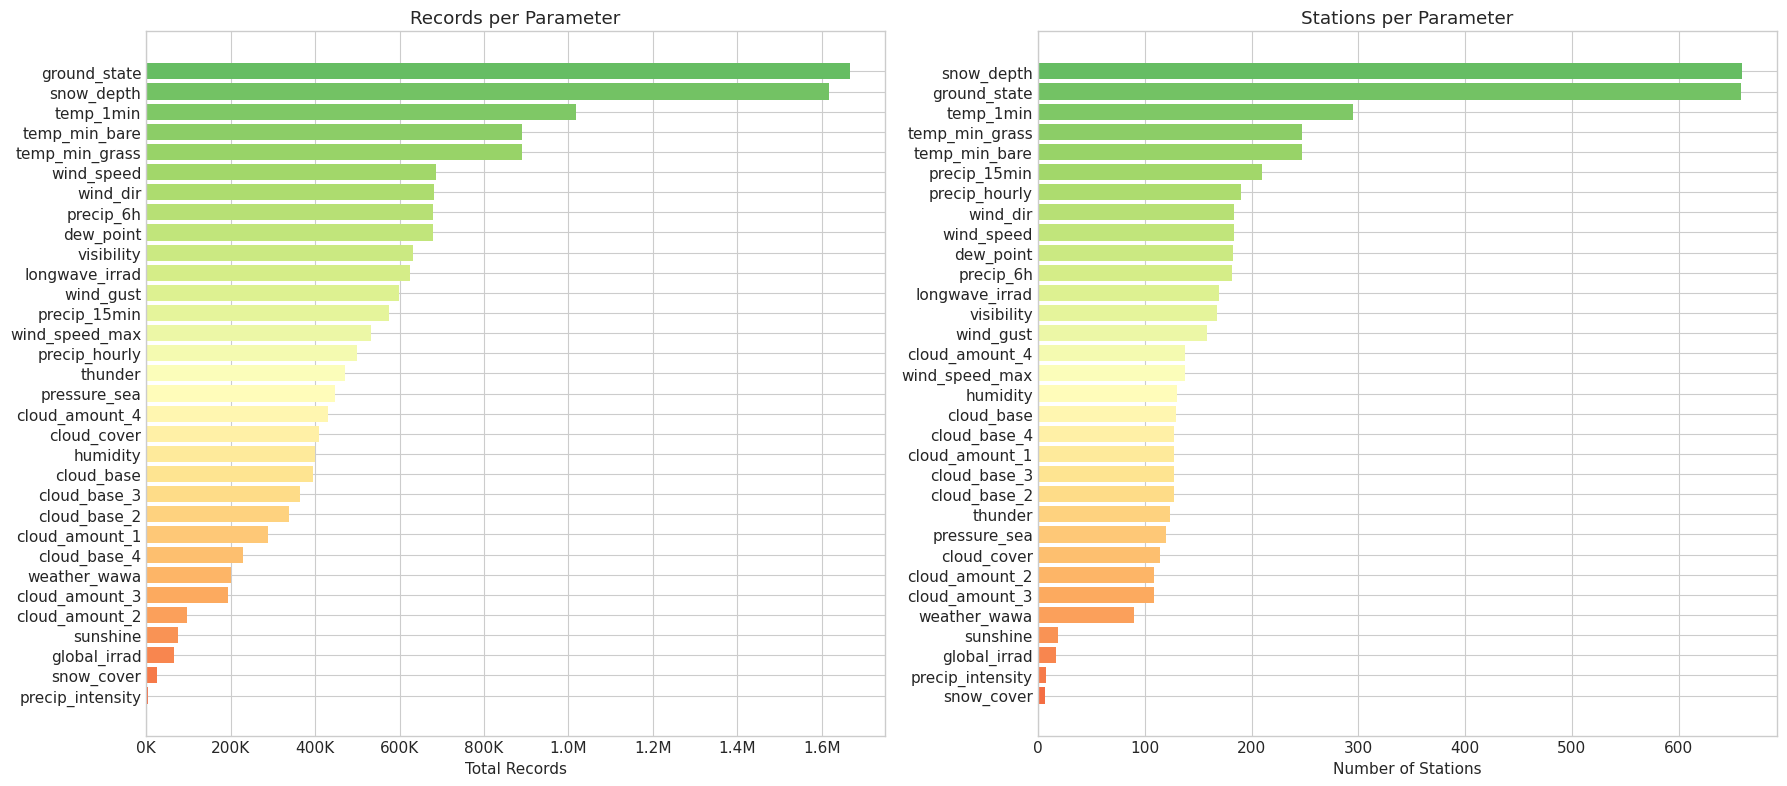

In [12]:
# Visualize parameter coverage
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Records per parameter
ax = axes[0]
sorted_df = analysis_df.sort_values('total_records', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sorted_df)))
bars = ax.barh(sorted_df['param_name'], sorted_df['total_records'], color=colors)
ax.set_xlabel('Total Records')
ax.set_title('Records per Parameter')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

# Stations per parameter
ax = axes[1]
sorted_df = analysis_df.sort_values('unique_stations', ascending=True)
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(sorted_df)))
bars = ax.barh(sorted_df['param_name'], sorted_df['unique_stations'], color=colors)
ax.set_xlabel('Number of Stations')
ax.set_title('Stations per Parameter')

plt.tight_layout()
plt.show()

---
# Part 5: Find Common Stations

This is the key analysis - finding which stations have data for multiple parameters we need.

In [13]:
# Build station-parameter matrix
print("=" * 100)
print("BUILDING STATION-PARAMETER MATRIX")
print("=" * 100)

# Collect all unique stations
all_stations = set()
station_params = defaultdict(set)  # station_id -> set of param_ids
station_info = {}  # station_id -> station info

for stats in param_analysis:
    param_id = stats['param_id']
    param_name = stats['param_name']
    
    # Load the file to get station details
    f = OUTPUT_DIR / f"param_{param_id:02d}_{param_name}.csv"
    df = pd.read_csv(f)
    
    for _, row in df.drop_duplicates('station_id').iterrows():
        sid = row['station_id']
        all_stations.add(sid)
        station_params[sid].add(param_id)
        
        if sid not in station_info:
            station_info[sid] = {
                'station_id': sid,
                'station_name': row['station_name'],
                'latitude': row['latitude'],
                'longitude': row['longitude'],
                'elevation': row['elevation']
            }

print(f"\nTotal unique stations across all parameters: {len(all_stations)}")

BUILDING STATION-PARAMETER MATRIX

Total unique stations across all parameters: 936


In [14]:
# Count parameters per station
station_param_counts = []

for sid, params in station_params.items():
    info = station_info.get(sid, {})
    station_param_counts.append({
        'station_id': sid,
        'station_name': info.get('station_name', 'Unknown'),
        'latitude': info.get('latitude'),
        'longitude': info.get('longitude'),
        'elevation': info.get('elevation'),
        'param_count': len(params),
        'param_ids': sorted(params),
    })

station_counts_df = pd.DataFrame(station_param_counts)
station_counts_df = station_counts_df.sort_values('param_count', ascending=False)

In [15]:
# Distribution of parameter counts
print("\n" + "=" * 100)
print("PARAMETER COUNT DISTRIBUTION")
print("=" * 100)

count_dist = station_counts_df['param_count'].value_counts().sort_index(ascending=False)

print(f"\n{'Params':<10} {'Stations':<10} {'Cumulative':<15}")
print("-" * 35)

cumulative = 0
for count, num_stations in count_dist.items():
    cumulative += num_stations
    print(f"{count:<10} {num_stations:<10} {cumulative:<15}")


PARAMETER COUNT DISTRIBUTION

Params     Stations   Cumulative     
-----------------------------------
29         1          1              
28         2          3              
27         1          4              
26         56         60             
25         27         87             
24         1          88             
23         1          89             
22         7          96             
21         1          97             
20         12         109            
19         18         127            
17         3          130            
16         6          136            
15         14         150            
14         13         163            
13         3          166            
12         2          168            
10         2          170            
9          10         180            
6          4          184            
5          66         250            
4          2          252            
3          32         284            
2          626       

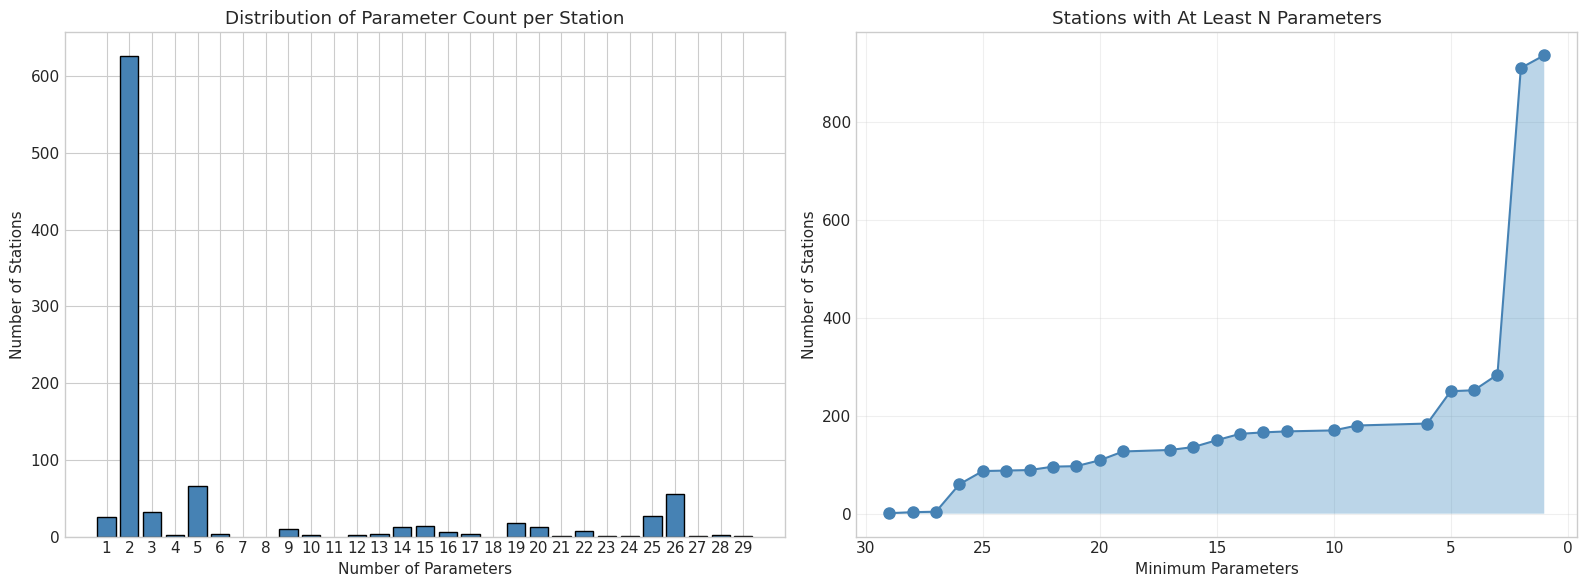

In [16]:
# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax = axes[0]
ax.bar(count_dist.index, count_dist.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Parameters')
ax.set_ylabel('Number of Stations')
ax.set_title('Distribution of Parameter Count per Station')
ax.set_xticks(range(1, count_dist.index.max() + 1))

# Cumulative
ax = axes[1]
cumsum = count_dist.sort_index(ascending=False).cumsum()
ax.plot(cumsum.index, cumsum.values, 'o-', markersize=8, color='steelblue')
ax.fill_between(cumsum.index, cumsum.values, alpha=0.3)
ax.set_xlabel('Minimum Parameters')
ax.set_ylabel('Number of Stations')
ax.set_title('Stations with At Least N Parameters')
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Show top stations by parameter count
print("\n" + "=" * 100)
print("TOP 30 STATIONS BY PARAMETER COUNT")
print("=" * 100)

top_stations = station_counts_df.head(30)[['station_name', 'station_id', 'param_count', 
                                            'latitude', 'longitude', 'elevation']]
display(top_stations.style.background_gradient(subset=['param_count'], cmap='Greens'))


TOP 30 STATIONS BY PARAMETER COUNT


,station_name,station_id,param_count,latitude,longitude,elevation
180,Norrköping-SMHI,86340,29,58.582800,16.147000,40.334000
1,Abisko Aut,188790,28,68.353800,18.816400,392.235000
6,Arjeplog A,167710,28,66.051300,17.839600,430.839000
202,Rångedala A,73480,27,57.784600,13.164200,297.467000
123,Kolmården-Strömsfors A,86420,26,58.689200,16.306900,153.613000
118,Kettstaka A,85460,26,58.716200,15.027100,224.876000
117,Kerstinbo A,106160,26,60.268300,16.973800,55.695000
132,Kvikkjokk-Årrenjarka A,167990,26,66.887400,18.019800,314.692000
146,Ljungby A,63510,26,56.852500,13.879400,148.485000
63,Gårdsjö A,84520,26,58.876800,14.387500,210.675000


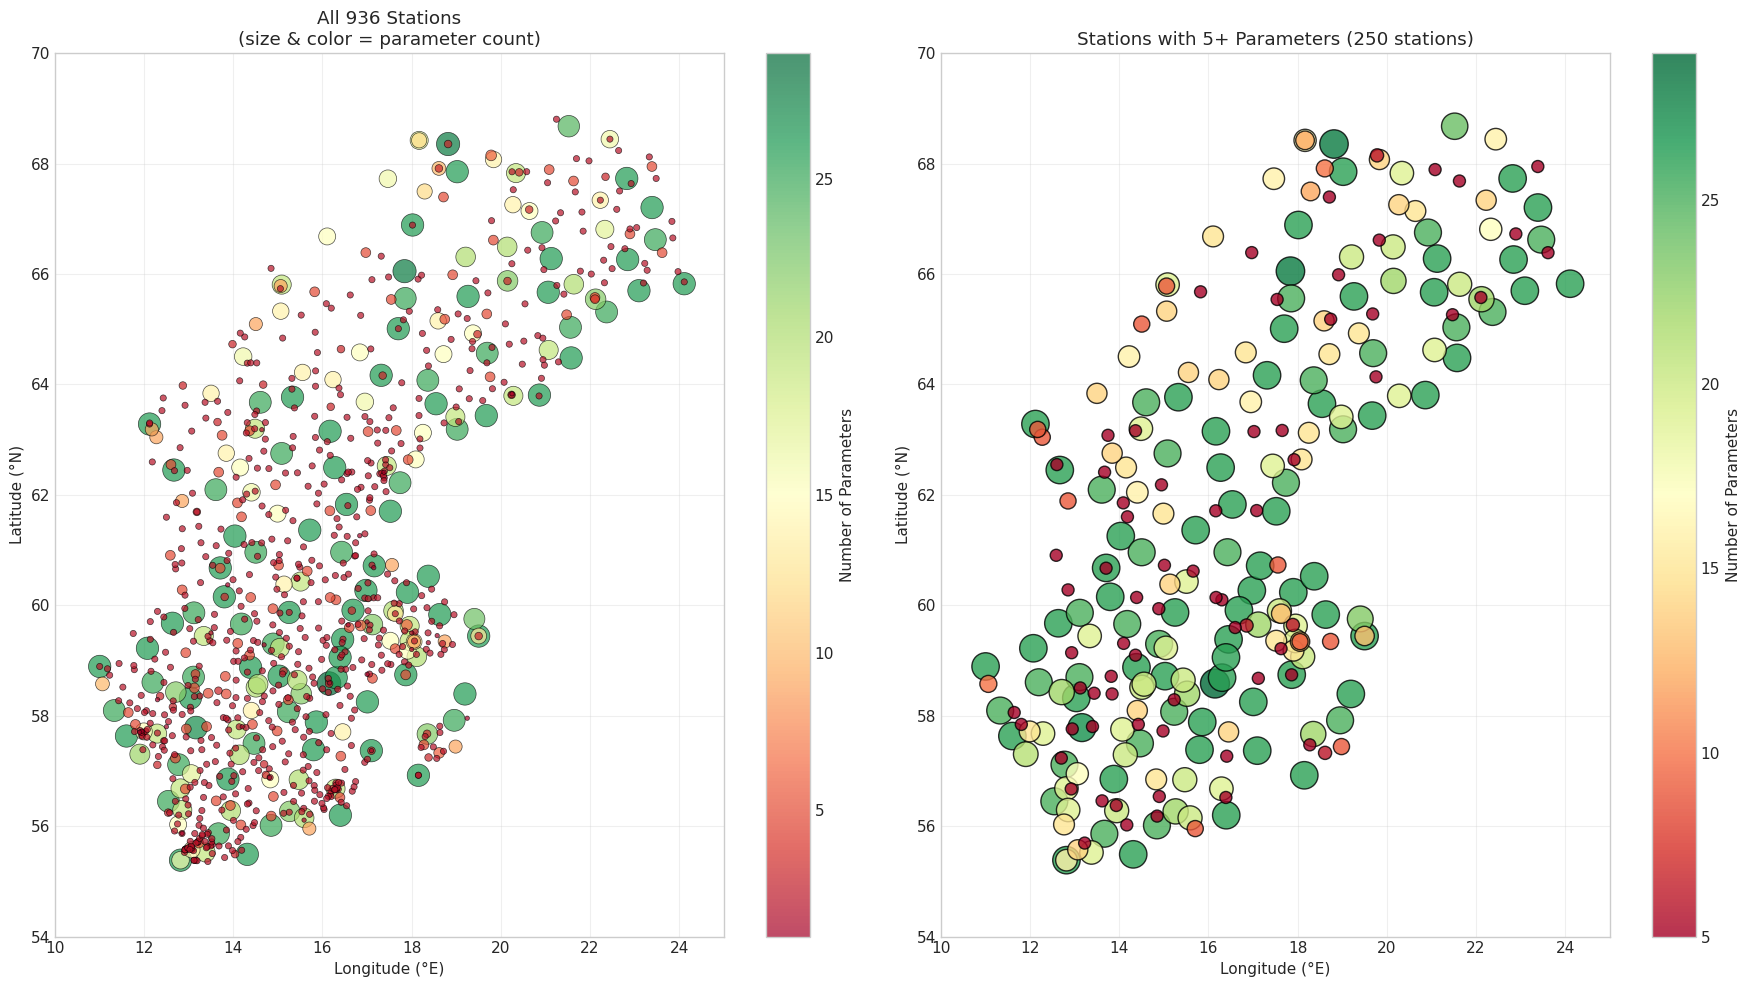

In [18]:
# Geographic distribution of multi-parameter stations
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# All stations
ax = axes[0]
scatter = ax.scatter(station_counts_df['longitude'], station_counts_df['latitude'],
                    c=station_counts_df['param_count'], cmap='RdYlGn',
                    s=station_counts_df['param_count'] * 10, alpha=0.7,
                    edgecolors='black', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Number of Parameters')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'All {len(station_counts_df)} Stations\n(size & color = parameter count)')
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)
ax.grid(True, alpha=0.3)

# Stations with 5+ parameters
ax = axes[1]
multi_param = station_counts_df[station_counts_df['param_count'] >= 5]
scatter = ax.scatter(multi_param['longitude'], multi_param['latitude'],
                    c=multi_param['param_count'], cmap='RdYlGn',
                    s=multi_param['param_count'] * 15, alpha=0.8,
                    edgecolors='black', linewidth=1)
plt.colorbar(scatter, ax=ax, label='Number of Parameters')
ax.set_xlabel('Longitude (°E)')
ax.set_ylabel('Latitude (°N)')
ax.set_title(f'Stations with 5+ Parameters ({len(multi_param)} stations)')
ax.set_xlim(10, 25)
ax.set_ylim(54, 70)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part 6: Key Parameter Overlap Analysis

For snow monitoring, we need specific parameters. Let's find stations that have our key parameters.

In [19]:
# Define key parameters for snow monitoring
KEY_PARAMS = {
    8: 'snow_depth',      # Primary target
    2: 'temp_mean',       # Temperature
    19: 'temp_min',       # Min temperature
    20: 'temp_max',       # Max temperature
    5: 'precip_sum',      # Precipitation
    4: 'wind_speed',      # Wind
    9: 'pressure_sea',    # Pressure
    29: 'humidity',       # Humidity
    39: 'dew_point',      # Dew point
    16: 'cloud_cover',    # Cloud cover
}

print("Key parameters for snow monitoring:")
for pid, name in KEY_PARAMS.items():
    # Check if we have this parameter
    if pid in [s['param_id'] for s in param_analysis]:
        stats = [s for s in param_analysis if s['param_id'] == pid][0]
        print(f"  ✓ {pid:>2}: {name:<15} - {stats['unique_stations']:>4} stations, {stats['total_records']:>10,} records")
    else:
        print(f"  ✗ {pid:>2}: {name:<15} - NOT DOWNLOADED")

Key parameters for snow monitoring:
  ✓  8: snow_depth      -  659 stations,  1,616,151 records
  ✗  2: temp_mean       - NOT DOWNLOADED
  ✗ 19: temp_min        - NOT DOWNLOADED
  ✗ 20: temp_max        - NOT DOWNLOADED
  ✗  5: precip_sum      - NOT DOWNLOADED
  ✓  4: wind_speed      -  184 stations,    685,749 records
  ✓  9: pressure_sea    -  120 stations,    448,061 records
  ✓ 29: humidity        -  130 stations,    399,004 records
  ✓ 39: dew_point       -  183 stations,    679,182 records
  ✓ 16: cloud_cover     -  114 stations,    410,487 records


In [20]:
# Find stations that have snow + other key parameters
print("\n" + "=" * 100)
print("STATIONS WITH SNOW DEPTH + OTHER KEY PARAMETERS")
print("=" * 100)

# Get stations with snow depth (param 8)
snow_stations = set()
for sid, params in station_params.items():
    if 8 in params:
        snow_stations.add(sid)

print(f"\nStations with snow depth data: {len(snow_stations)}")

# Count how many key params each snow station has
snow_station_analysis = []

for sid in snow_stations:
    params = station_params[sid]
    key_param_count = sum(1 for p in KEY_PARAMS.keys() if p in params)
    key_params_present = [KEY_PARAMS[p] for p in KEY_PARAMS.keys() if p in params]
    
    info = station_info.get(sid, {})
    snow_station_analysis.append({
        'station_id': sid,
        'station_name': info.get('station_name', 'Unknown'),
        'latitude': info.get('latitude'),
        'longitude': info.get('longitude'),
        'elevation': info.get('elevation'),
        'key_param_count': key_param_count,
        'total_param_count': len(params),
        'key_params': ', '.join(key_params_present),
    })

snow_analysis_df = pd.DataFrame(snow_station_analysis)
snow_analysis_df = snow_analysis_df.sort_values('key_param_count', ascending=False)


STATIONS WITH SNOW DEPTH + OTHER KEY PARAMETERS

Stations with snow depth data: 659


In [21]:
# Distribution of key parameters for snow stations
print("\nDistribution of key parameters among snow stations:")
key_dist = snow_analysis_df['key_param_count'].value_counts().sort_index(ascending=False)

print(f"\n{'Key Params':<15} {'Stations':<10}")
print("-" * 25)
for count, num in key_dist.items():
    print(f"{count:<15} {num:<10}")


Distribution of key parameters among snow stations:

Key Params      Stations  
-------------------------
6               10        
5               1         
4               4         
3               1         
1               643       


In [22]:
# Top snow stations with most key parameters
print("\n" + "=" * 100)
print("TOP 25 SNOW STATIONS BY KEY PARAMETER COUNT")
print("=" * 100)

top_snow = snow_analysis_df.head(25)
display(top_snow[['station_name', 'station_id', 'key_param_count', 'total_param_count', 
                  'latitude', 'elevation', 'key_params']].style.background_gradient(
    subset=['key_param_count'], cmap='Greens'))


TOP 25 SNOW STATIONS BY KEY PARAMETER COUNT


,station_name,station_id,key_param_count,total_param_count,latitude,elevation,key_params
359,Enköping,97370,6,22,59.650000,24.600000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
398,Vidsel,160970,6,22,65.875000,182.566000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
120,Såtenäs,82260,6,22,58.428000,55.100000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
577,Arjeplog A,167710,6,28,66.051300,430.839000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
323,Falsterbo,52230,6,16,55.383700,1.541000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
340,Luleå-Kallax Flygplats,162860,6,22,65.543000,19.900000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
530,Ronneby-Bredåkra,65160,6,22,56.267000,58.200000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
413,Linköping-Malmslätt,85240,6,22,58.398000,94.000000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
129,Abisko Aut,188790,6,28,68.353800,392.235000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"
118,Norrköping-SMHI,86340,6,29,58.582800,40.334000,"snow_depth, wind_speed, pressure_sea, humidity, dew_point, cloud_cover"



PARAMETER AVAILABILITY FOR TOP SNOW STATIONS


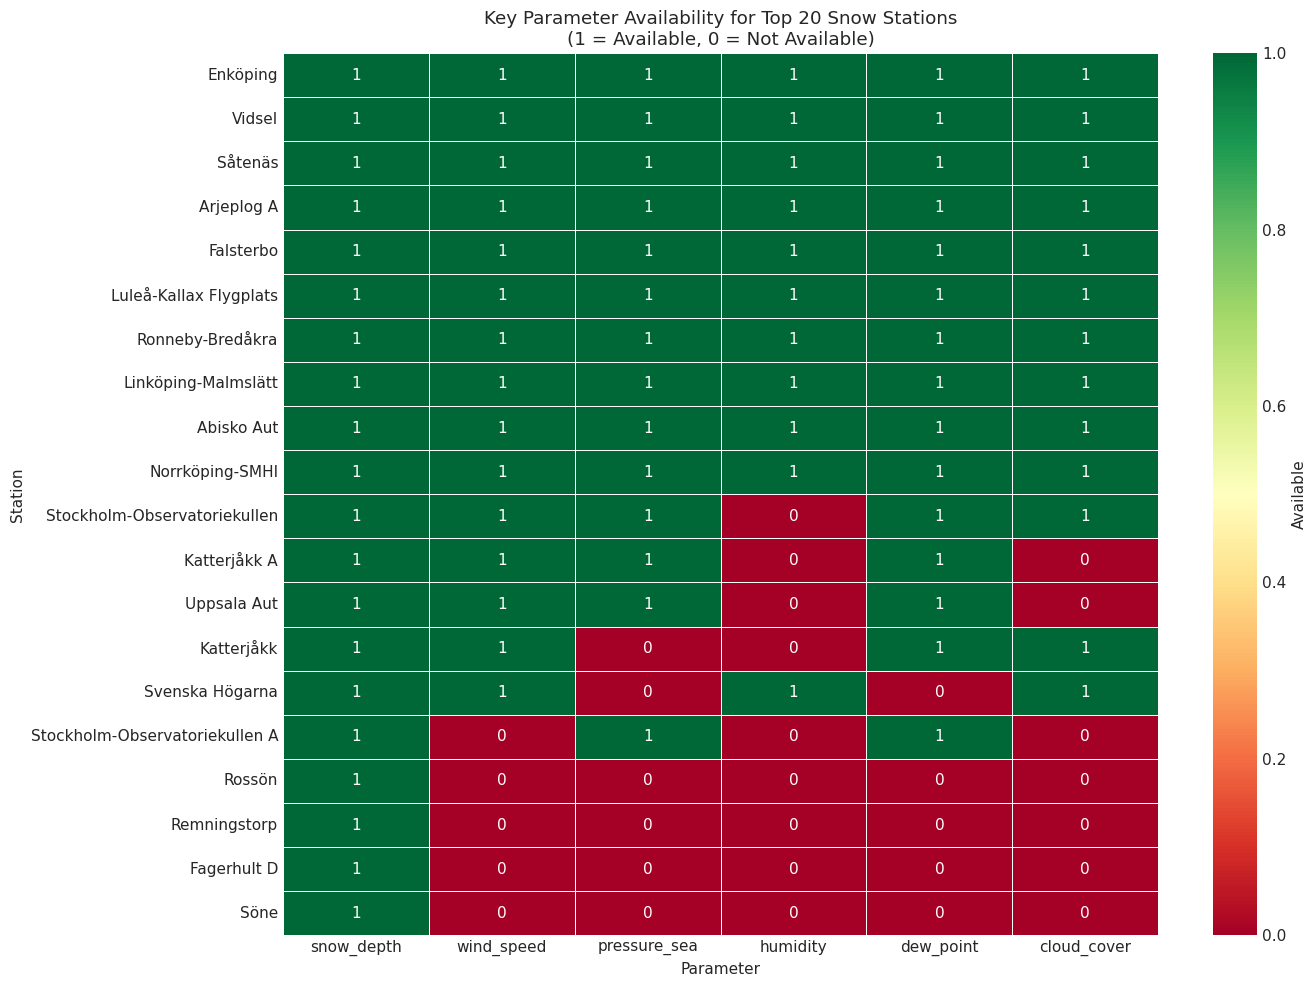

In [23]:
# Parameter overlap heatmap for top stations
print("\n" + "=" * 100)
print("PARAMETER AVAILABILITY FOR TOP SNOW STATIONS")
print("=" * 100)

# Create matrix for top 20 snow stations
top_20_snow = snow_analysis_df.head(20)
available_key_params = [p for p in KEY_PARAMS.keys() if p in [s['param_id'] for s in param_analysis]]

matrix_data = []
for _, row in top_20_snow.iterrows():
    sid = row['station_id']
    params = station_params[sid]
    row_data = {'station': row['station_name']}
    for pid in available_key_params:
        row_data[KEY_PARAMS[pid]] = 1 if pid in params else 0
    matrix_data.append(row_data)

matrix_df = pd.DataFrame(matrix_data)
matrix_df = matrix_df.set_index('station')

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(matrix_df, annot=True, fmt='d', cmap='RdYlGn', 
            cbar_kws={'label': 'Available'}, ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('Key Parameter Availability for Top 20 Snow Stations\n(1 = Available, 0 = Not Available)')
ax.set_xlabel('Parameter')
ax.set_ylabel('Station')
plt.tight_layout()
plt.show()

---
# Part 7: Recommendations & Summary

In [24]:
# Generate final recommendations
print("=" * 100)
print("FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 100)

print(f"""
DOWNLOADED DATA SUMMARY:
  • Parameters downloaded: {len(param_analysis)}
  • Total unique stations: {len(all_stations)}
  • Date range: {START_DATE} to {END_DATE}
  • Output directory: {OUTPUT_DIR.absolute()}

PARAMETER COVERAGE (top 5 by stations):
""")

for _, row in analysis_df.head(5).iterrows():
    print(f"  • {row['param_name']:<20}: {row['unique_stations']:>4} stations, {row['total_records']:>10,} records")

print(f"""
SNOW STATIONS ANALYSIS:
  • Total stations with snow depth: {len(snow_stations)}
  • Stations with snow + 5 key params: {len(snow_analysis_df[snow_analysis_df['key_param_count'] >= 5])}
  • Stations with snow + 3 key params: {len(snow_analysis_df[snow_analysis_df['key_param_count'] >= 3])}
""")

FINAL SUMMARY & RECOMMENDATIONS

DOWNLOADED DATA SUMMARY:
  • Parameters downloaded: 32
  • Total unique stations: 936
  • Date range: 2015-01-01 to 2025-12-31
  • Output directory: /scratch/gdemil24/RISE/nordic-snow-monitoring/notebooks/../data/raw/parameters

PARAMETER COVERAGE (top 5 by stations):

  • ground_state        :  658 stations,  1,666,837 records
  • snow_depth          :  659 stations,  1,616,151 records
  • temp_1min           :  295 stations,  1,017,296 records
  • temp_min_bare       :  247 stations,    890,711 records
  • temp_min_grass      :  247 stations,    890,708 records

SNOW STATIONS ANALYSIS:
  • Total stations with snow depth: 659
  • Stations with snow + 5 key params: 11
  • Stations with snow + 3 key params: 16



In [25]:
# Save analysis results
print("\nSaving analysis results...")

# Parameter summary
analysis_df.drop('stations', axis=1).to_csv(OUTPUT_DIR / '_parameter_summary.csv', index=False)
print(f"  ✓ Saved: _parameter_summary.csv")

# Station-parameter counts
station_counts_df.drop('param_ids', axis=1).to_csv(OUTPUT_DIR / '_station_param_counts.csv', index=False)
print(f"  ✓ Saved: _station_param_counts.csv")

# Snow station analysis
snow_analysis_df.to_csv(OUTPUT_DIR / '_snow_station_analysis.csv', index=False)
print(f"  ✓ Saved: _snow_station_analysis.csv")

print("\nAnalysis complete!")


Saving analysis results...
  ✓ Saved: _parameter_summary.csv
  ✓ Saved: _station_param_counts.csv
  ✓ Saved: _snow_station_analysis.csv

Analysis complete!


In [26]:
# Final recommendations
print("\n" + "=" * 100)
print("RECOMMENDED NEXT STEPS")
print("=" * 100)

print("""
OPTION 1: Use stations with most key parameters
  • Select top N stations from _snow_station_analysis.csv
  • Merge individual parameter files for these stations
  • Good for: Multi-task model with rich features

OPTION 2: Use all snow stations + available params
  • Use all stations with snow_depth
  • Add parameters that are widely available (e.g., temp, precip)
  • Accept missing values for less common parameters
  • Good for: Maximum geographic coverage

OPTION 3: Parameter-specific analysis
  • Choose specific parameters based on analysis
  • Find intersection of stations for those params
  • Good for: Targeted feature selection

FILES CREATED:
  • Individual parameter CSVs: data/raw/parameters/param_XX_name.csv
  • Parameter summary: data/raw/parameters/_parameter_summary.csv
  • Station counts: data/raw/parameters/_station_param_counts.csv
  • Snow analysis: data/raw/parameters/_snow_station_analysis.csv
""")


RECOMMENDED NEXT STEPS

OPTION 1: Use stations with most key parameters
  • Select top N stations from _snow_station_analysis.csv
  • Merge individual parameter files for these stations
  • Good for: Multi-task model with rich features

OPTION 2: Use all snow stations + available params
  • Use all stations with snow_depth
  • Add parameters that are widely available (e.g., temp, precip)
  • Accept missing values for less common parameters
  • Good for: Maximum geographic coverage

OPTION 3: Parameter-specific analysis
  • Choose specific parameters based on analysis
  • Find intersection of stations for those params
  • Good for: Targeted feature selection

FILES CREATED:
  • Individual parameter CSVs: data/raw/parameters/param_XX_name.csv
  • Parameter summary: data/raw/parameters/_parameter_summary.csv
  • Station counts: data/raw/parameters/_station_param_counts.csv
  • Snow analysis: data/raw/parameters/_snow_station_analysis.csv



---
# Appendix: Quick Data Access

Use these snippets to load and merge specific parameters for your model.

In [27]:
# Example: Load and merge specific parameters for selected stations
def load_and_merge_params(param_ids: List[int], station_ids: Optional[List[int]] = None) -> pd.DataFrame:
    """
    Load and merge specific parameters for selected stations.
    
    Args:
        param_ids: List of parameter IDs to load
        station_ids: Optional list of station IDs to filter (None = all)
    
    Returns:
        Merged DataFrame with all parameters
    """
    dfs = []
    
    for pid in param_ids:
        if pid not in SMHI_PARAMETERS:
            print(f"Warning: Unknown parameter ID {pid}")
            continue
            
        param_name = SMHI_PARAMETERS[pid]['name']
        param_file = OUTPUT_DIR / f"param_{pid:02d}_{param_name}.csv"
        
        if not param_file.exists():
            print(f"Warning: File not found for parameter {pid} ({param_name})")
            continue
        
        df = pd.read_csv(param_file, parse_dates=['date'])
        
        # Filter stations if specified
        if station_ids:
            df = df[df['station_id'].isin(station_ids)]
        
        dfs.append(df)
        print(f"Loaded {param_name}: {len(df):,} records")
    
    if not dfs:
        return pd.DataFrame()
    
    # Merge on station_id and date
    merged = dfs[0]
    for df in dfs[1:]:
        # Get the parameter column (last column)
        param_col = df.columns[-1]
        merge_cols = ['date', 'station_id']
        merged = merged.merge(
            df[merge_cols + [param_col]], 
            on=merge_cols, 
            how='outer'
        )
    
    # Fill station info for outer joins
    merged = merged.sort_values(['station_name', 'date'])
    
    return merged

# Example usage (uncomment to run):
# merged_df = load_and_merge_params(
#     param_ids=[8, 2, 5, 4],  # snow, temp, precip, wind
#     station_ids=None  # All stations
# )
# print(f"\nMerged shape: {merged_df.shape}")
# display(merged_df.head())

Starting download at 2026-01-26 11:57:45
Parameters to process: 39
Date range: 2015-01-01 to 2025-12-31

======================================================================

[1/39] Processing...

======================================================================
DOWNLOADING: Parameter 8 - snow_depth
Description: Snow depth (daily)
======================================================================

Querying available stations...
Found 1896 stations with snow_depth data
  Progress: 1/1896 stations...
  Progress: 50/1896 stations...
  Progress: 100/1896 stations...
  Progress: 150/1896 stations...
  Progress: 200/1896 stations...
  Progress: 250/1896 stations...
  Progress: 300/1896 stations...
  Progress: 350/1896 stations...
  Progress: 400/1896 stations...
  Progress: 450/1896 stations...
  Progress: 500/1896 stations...
  Progress: 550/1896 stations...
  Progress: 600/1896 stations...
  Progress: 650/1896 stations...
  Progress: 700/1896 stations...
  Progress: 750/1896 stations...
  Progress: 800/1896 stations...
  Progress: 850/1896 stations...
  Progress: 900/1896 stations...
  Progress: 950/1896 stations...
  Progress: 1000/1896 stations...
  Progress: 1050/1896 stations...
  Progress: 1100/1896 stations...
  Progress: 1150/1896 stations...
  Progress: 1200/1896 stations...
  Progress: 1250/1896 stations...
  Progress: 1300/1896 stations...
  Progress: 1350/1896 stations...
  Progress: 1400/1896 stations...
  Progress: 1450/1896 stations...
  Progress: 1500/1896 stations...
  Progress: 1550/1896 stations...
  Progress: 1600/1896 stations...
  Progress: 1650/1896 stations...
  Progress: 1700/1896 stations...
  Progress: 1750/1896 stations...
  Progress: 1800/1896 stations...
  Progress: 1850/1896 stations...

  Stations with data: 659/1896
  Total records: 1,616,151
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_08_snow_depth.csv

[2/39] Processing...

======================================================================
DOWNLOADING: Parameter 2 - temp_mean
Description: Air temperature (daily mean)
======================================================================

Querying available stations...
Found 935 stations with temp_mean data
  Progress: 1/935 stations...
  Progress: 50/935 stations...
  Progress: 100/935 stations...
  Progress: 150/935 stations...
  Progress: 200/935 stations...
  Progress: 250/935 stations...
  Progress: 300/935 stations...
  Progress: 350/935 stations...
  Progress: 400/935 stations...
  Progress: 450/935 stations...
  Progress: 500/935 stations...
  Progress: 550/935 stations...
  Progress: 600/935 stations...
  Progress: 650/935 stations...
  Progress: 700/935 stations...
  Progress: 750/935 stations...
  Progress: 800/935 stations...
  Progress: 850/935 stations...
  Progress: 900/935 stations...

No data retrieved for temp_mean

[3/39] Processing...

======================================================================
DOWNLOADING: Parameter 19 - temp_min
Description: Air temperature (daily min)
======================================================================

Querying available stations...
Found 942 stations with temp_min data
  Progress: 1/942 stations...
  Progress: 50/942 stations...
  Progress: 100/942 stations...
  Progress: 150/942 stations...
  Progress: 200/942 stations...
  Progress: 250/942 stations...
  Progress: 300/942 stations...
  Progress: 350/942 stations...
  Progress: 400/942 stations...
  Progress: 450/942 stations...
  Progress: 500/942 stations...
  Progress: 550/942 stations...
  Progress: 600/942 stations...
  Progress: 650/942 stations...
  Progress: 700/942 stations...
  Progress: 750/942 stations...
  Progress: 800/942 stations...
  Progress: 850/942 stations...
  Progress: 900/942 stations...

No data retrieved for temp_min

[4/39] Processing...

======================================================================
DOWNLOADING: Parameter 20 - temp_max
Description: Air temperature (daily max)
======================================================================

Querying available stations...
Found 934 stations with temp_max data
  Progress: 1/934 stations...
  Progress: 50/934 stations...
  Progress: 100/934 stations...
  Progress: 150/934 stations...
  Progress: 200/934 stations...
  Progress: 250/934 stations...
  Progress: 300/934 stations...
  Progress: 350/934 stations...
  Progress: 400/934 stations...
  Progress: 450/934 stations...
  Progress: 500/934 stations...
  Progress: 550/934 stations...
  Progress: 600/934 stations...
  Progress: 650/934 stations...
  Progress: 700/934 stations...
  Progress: 750/934 stations...
  Progress: 800/934 stations...
  Progress: 850/934 stations...
  Progress: 900/934 stations...

No data retrieved for temp_max

[5/39] Processing...

======================================================================
DOWNLOADING: Parameter 5 - precip_sum
Description: Precipitation (daily sum)
======================================================================

Querying available stations...
Found 2182 stations with precip_sum data
  Progress: 1/2182 stations...
  Progress: 50/2182 stations...
  Progress: 100/2182 stations...
  Progress: 150/2182 stations...
  Progress: 200/2182 stations...
  Progress: 250/2182 stations...
  Progress: 300/2182 stations...
  Progress: 350/2182 stations...
  Progress: 400/2182 stations...
  Progress: 450/2182 stations...
  Progress: 500/2182 stations...
  Progress: 550/2182 stations...
  Progress: 600/2182 stations...
  Progress: 650/2182 stations...
  Progress: 700/2182 stations...
  Progress: 750/2182 stations...
  Progress: 800/2182 stations...
  Progress: 850/2182 stations...
  Progress: 900/2182 stations...
  Progress: 950/2182 stations...
  Progress: 1000/2182 stations...
  Progress: 1050/2182 stations...
  Progress: 1100/2182 stations...
  Progress: 1150/2182 stations...
  Progress: 1200/2182 stations...
  Progress: 1250/2182 stations...
  Progress: 1300/2182 stations...
  Progress: 1350/2182 stations...
  Progress: 1400/2182 stations...
  Progress: 1450/2182 stations...
  Progress: 1500/2182 stations...
  Progress: 1550/2182 stations...
  Progress: 1600/2182 stations...
  Progress: 1650/2182 stations...
  Progress: 1700/2182 stations...
  Progress: 1750/2182 stations...
  Progress: 1800/2182 stations...
  Progress: 1850/2182 stations...
  Progress: 1900/2182 stations...
  Progress: 1950/2182 stations...
  Progress: 2000/2182 stations...
  Progress: 2050/2182 stations...
  Progress: 2100/2182 stations...
  Progress: 2150/2182 stations...

No data retrieved for precip_sum

[6/39] Processing...

======================================================================
DOWNLOADING: Parameter 4 - wind_speed
Description: Wind speed (10-min mean)
======================================================================

Querying available stations...
Found 528 stations with wind_speed data
  Progress: 1/528 stations...
  Progress: 50/528 stations...
  Progress: 100/528 stations...
  Progress: 150/528 stations...
  Progress: 200/528 stations...
  Progress: 250/528 stations...
  Progress: 300/528 stations...
  Progress: 350/528 stations...
  Progress: 400/528 stations...
  Progress: 450/528 stations...
  Progress: 500/528 stations...

  Stations with data: 184/528
  Total records: 685,749
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_04_wind_speed.csv

[7/39] Processing...

======================================================================
DOWNLOADING: Parameter 9 - pressure_sea
Description: Sea-level pressure
======================================================================

Querying available stations...
Found 400 stations with pressure_sea data
  Progress: 1/400 stations...
  Progress: 50/400 stations...
  Progress: 100/400 stations...
  Progress: 150/400 stations...
  Progress: 200/400 stations...
  Progress: 250/400 stations...
  Progress: 300/400 stations...
  Progress: 350/400 stations...
  Progress: 400/400 stations...

  Stations with data: 120/400
  Total records: 448,061
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_09_pressure_sea.csv

[8/39] Processing...

======================================================================
DOWNLOADING: Parameter 29 - humidity
Description: Relative humidity
======================================================================

Querying available stations...
Found 213 stations with humidity data
  Progress: 1/213 stations...
  Progress: 50/213 stations...
  Progress: 100/213 stations...
  Progress: 150/213 stations...
  Progress: 200/213 stations...

  Stations with data: 130/213
  Total records: 399,004
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_29_humidity.csv

[9/39] Processing...

======================================================================
DOWNLOADING: Parameter 39 - dew_point
Description: Dew point temperature
======================================================================

Querying available stations...
Found 512 stations with dew_point data
  Progress: 1/512 stations...
  Progress: 50/512 stations...
  Progress: 100/512 stations...
  Progress: 150/512 stations...
  Progress: 200/512 stations...
  Progress: 250/512 stations...
  Progress: 300/512 stations...
  Progress: 350/512 stations...
  Progress: 400/512 stations...
  Progress: 450/512 stations...
  Progress: 500/512 stations...

  Stations with data: 183/512
  Total records: 679,182
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_39_dew_point.csv

[10/39] Processing...

======================================================================
DOWNLOADING: Parameter 16 - cloud_cover
Description: Total cloud cover
======================================================================

Querying available stations...
Found 459 stations with cloud_cover data
  Progress: 1/459 stations...
  Progress: 50/459 stations...
  Progress: 100/459 stations...
  Progress: 150/459 stations...
  Progress: 200/459 stations...
  Progress: 250/459 stations...
  Progress: 300/459 stations...
  Progress: 350/459 stations...
  Progress: 400/459 stations...
  Progress: 450/459 stations...

  Stations with data: 114/459
  Total records: 410,487
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_16_cloud_cover.csv

[11/39] Processing...

======================================================================
DOWNLOADING: Parameter 40 - ground_state
Description: Ground state code
======================================================================

Querying available stations...
Found 1895 stations with ground_state data
  Progress: 1/1895 stations...
  Progress: 50/1895 stations...
  Progress: 100/1895 stations...
  Progress: 150/1895 stations...
  Progress: 200/1895 stations...
  Progress: 250/1895 stations...
  Progress: 300/1895 stations...
  Progress: 350/1895 stations...
  Progress: 400/1895 stations...
  Progress: 450/1895 stations...
  Progress: 500/1895 stations...
  Progress: 550/1895 stations...
  Progress: 600/1895 stations...
  Progress: 650/1895 stations...
  Progress: 700/1895 stations...
  Progress: 750/1895 stations...
  Progress: 800/1895 stations...
  Progress: 850/1895 stations...
  Progress: 900/1895 stations...
  Progress: 950/1895 stations...
  Progress: 1000/1895 stations...
  Progress: 1050/1895 stations...
  Progress: 1100/1895 stations...
  Progress: 1150/1895 stations...
  Progress: 1200/1895 stations...
  Progress: 1250/1895 stations...
  Progress: 1300/1895 stations...
  Progress: 1350/1895 stations...
  Progress: 1400/1895 stations...
  Progress: 1450/1895 stations...
  Progress: 1500/1895 stations...
  Progress: 1550/1895 stations...
  Progress: 1600/1895 stations...
  Progress: 1650/1895 stations...
  Progress: 1700/1895 stations...
  Progress: 1750/1895 stations...
  Progress: 1800/1895 stations...
  Progress: 1850/1895 stations...

  Stations with data: 658/1895
  Total records: 1,666,837
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_40_ground_state.csv

[12/39] Processing...

======================================================================
DOWNLOADING: Parameter 10 - sunshine
Description: Sunshine duration
======================================================================

Querying available stations...
Found 20 stations with sunshine data
  Progress: 1/20 stations...

  Stations with data: 19/20
  Total records: 74,608
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_10_sunshine.csv

[13/39] Processing...

======================================================================
DOWNLOADING: Parameter 21 - wind_gust
Description: Wind gust speed
======================================================================

Querying available stations...
Found 176 stations with wind_gust data
  Progress: 1/176 stations...
  Progress: 50/176 stations...
  Progress: 100/176 stations...
  Progress: 150/176 stations...

  Stations with data: 158/176
  Total records: 599,517
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_21_wind_gust.csv

[14/39] Processing...

======================================================================
DOWNLOADING: Parameter 1 - temp_1min
Description: Air temperature (1-min)
======================================================================

Querying available stations...
Found 994 stations with temp_1min data
  Progress: 1/994 stations...
  Progress: 50/994 stations...
  Progress: 100/994 stations...
  Progress: 150/994 stations...
  Progress: 200/994 stations...
  Progress: 250/994 stations...
  Progress: 300/994 stations...
  Progress: 350/994 stations...
  Progress: 400/994 stations...
  Progress: 450/994 stations...
  Progress: 500/994 stations...
  Progress: 550/994 stations...
  Progress: 600/994 stations...
  Progress: 650/994 stations...
  Progress: 700/994 stations...
  Progress: 750/994 stations...
  Progress: 800/994 stations...
  Progress: 850/994 stations...
  Progress: 900/994 stations...
  Progress: 950/994 stations...

  Stations with data: 295/994
  Total records: 1,017,296
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_01_temp_1min.csv

[15/39] Processing...

======================================================================
DOWNLOADING: Parameter 6 - precip_6h
Description: Precipitation (6-hourly)
======================================================================

Querying available stations...
Found 512 stations with precip_6h data
  Progress: 1/512 stations...
  Progress: 50/512 stations...
  Progress: 100/512 stations...
  Progress: 150/512 stations...
  Progress: 200/512 stations...
  Progress: 250/512 stations...
  Progress: 300/512 stations...
  Progress: 350/512 stations...
  Progress: 400/512 stations...
  Progress: 450/512 stations...
  Progress: 500/512 stations...

  Stations with data: 182/512
  Total records: 679,219
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_06_precip_6h.csv

[16/39] Processing...

======================================================================
DOWNLOADING: Parameter 7 - precip_15min
Description: Precipitation (15-min)
======================================================================

Querying available stations...
Found 236 stations with precip_15min data
  Progress: 1/236 stations...
  Progress: 50/236 stations...
  Progress: 100/236 stations...
  Progress: 150/236 stations...
  Progress: 200/236 stations...

  Stations with data: 210/236
  Total records: 575,456
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_07_precip_15min.csv

[17/39] Processing...

======================================================================
DOWNLOADING: Parameter 14 - precip_hourly
Description: Precipitation (hourly)
======================================================================

Querying available stations...
Found 208 stations with precip_hourly data
  Progress: 1/208 stations...
  Progress: 50/208 stations...
  Progress: 100/208 stations...
  Progress: 150/208 stations...
  Progress: 200/208 stations...

  Stations with data: 190/208
  Total records: 498,850
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_14_precip_hourly.csv

[18/39] Processing...

======================================================================
DOWNLOADING: Parameter 17 - precip_2x_daily
Description: Precipitation (2x daily)
======================================================================

Querying available stations...
Found 83 stations with precip_2x_daily data
  Progress: 1/83 stations...
  Progress: 50/83 stations...

No data retrieved for precip_2x_daily

[19/39] Processing...

======================================================================
DOWNLOADING: Parameter 23 - snow_type
Description: Snow type code
======================================================================

Querying available stations...
Found 2169 stations with snow_type data
  Progress: 1/2169 stations...
  Progress: 50/2169 stations...
  Progress: 100/2169 stations...
  Progress: 150/2169 stations...
  Progress: 200/2169 stations...
  Progress: 250/2169 stations...
  Progress: 300/2169 stations...
  Progress: 350/2169 stations...
  Progress: 400/2169 stations...
  Progress: 450/2169 stations...
  Progress: 500/2169 stations...
  Progress: 550/2169 stations...
  Progress: 600/2169 stations...
  Progress: 650/2169 stations...
  Progress: 700/2169 stations...
  Progress: 750/2169 stations...
  Progress: 800/2169 stations...
  Progress: 850/2169 stations...
  Progress: 900/2169 stations...
  Progress: 950/2169 stations...
  Progress: 1000/2169 stations...
  Progress: 1050/2169 stations...
  Progress: 1100/2169 stations...
  Progress: 1150/2169 stations...
  Progress: 1200/2169 stations...
  Progress: 1250/2169 stations...
  Progress: 1300/2169 stations...
  Progress: 1350/2169 stations...
  Progress: 1400/2169 stations...
  Progress: 1450/2169 stations...
  Progress: 1500/2169 stations...
  Progress: 1550/2169 stations...
  Progress: 1600/2169 stations...
  Progress: 1650/2169 stations...
  Progress: 1700/2169 stations...
  Progress: 1750/2169 stations...
  Progress: 1800/2169 stations...
  Progress: 1850/2169 stations...
  Progress: 1900/2169 stations...
  Progress: 1950/2169 stations...
  Progress: 2000/2169 stations...
  Progress: 2050/2169 stations...
  Progress: 2100/2169 stations...
  Progress: 2150/2169 stations...

No data retrieved for snow_type

[20/39] Processing...

======================================================================
DOWNLOADING: Parameter 3 - wind_dir
Description: Wind direction
======================================================================

Querying available stations...
Found 529 stations with wind_dir data
  Progress: 1/529 stations...
  Progress: 50/529 stations...
  Progress: 100/529 stations...
  Progress: 150/529 stations...
  Progress: 200/529 stations...
  Progress: 250/529 stations...
  Progress: 300/529 stations...
  Progress: 350/529 stations...
  Progress: 400/529 stations...
  Progress: 450/529 stations...
  Progress: 500/529 stations...

  Stations with data: 184/529
  Total records: 682,773
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_03_wind_dir.csv

[21/39] Processing...

======================================================================
DOWNLOADING: Parameter 25 - wind_speed_max
Description: Wind speed (daily max)
======================================================================

Querying available stations...
Found 295 stations with wind_speed_max data
  Progress: 1/295 stations...
  Progress: 50/295 stations...
  Progress: 100/295 stations...
  Progress: 150/295 stations...
  Progress: 200/295 stations...
  Progress: 250/295 stations...

  Stations with data: 138/295
  Total records: 533,131
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_25_wind_speed_max.csv

[22/39] Processing...

======================================================================
DOWNLOADING: Parameter 11 - global_irrad
Description: Global irradiance
======================================================================

Querying available stations...
Found 19 stations with global_irrad data
  Progress: 1/19 stations...

  Stations with data: 17/19
  Total records: 66,743
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_11_global_irrad.csv

[23/39] Processing...

======================================================================
DOWNLOADING: Parameter 12 - longwave_irrad
Description: Longwave irradiance
======================================================================

Querying available stations...
Found 512 stations with longwave_irrad data
  Progress: 1/512 stations...
  Progress: 50/512 stations...
  Progress: 100/512 stations...
  Progress: 150/512 stations...
  Progress: 200/512 stations...
  Progress: 250/512 stations...
  Progress: 300/512 stations...
  Progress: 350/512 stations...
  Progress: 400/512 stations...
  Progress: 450/512 stations...
  Progress: 500/512 stations...

  Stations with data: 170/512
  Total records: 623,709
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_12_longwave_irrad.csv

[24/39] Processing...

======================================================================
DOWNLOADING: Parameter 13 - visibility
Description: Visibility
======================================================================

Querying available stations...
Found 345 stations with visibility data
  Progress: 1/345 stations...
  Progress: 50/345 stations...
  Progress: 100/345 stations...
  Progress: 150/345 stations...
  Progress: 200/345 stations...
  Progress: 250/345 stations...
  Progress: 300/345 stations...

  Stations with data: 168/345
  Total records: 631,848
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_13_visibility.csv

[25/39] Processing...

======================================================================
DOWNLOADING: Parameter 15 - precip_intensity
Description: Precipitation intensity
======================================================================

Querying available stations...
Found 77 stations with precip_intensity data
  Progress: 1/77 stations...
  Progress: 50/77 stations...

  Stations with data: 8/77
  Total records: 4,190
  Date range: 2015-01-01 to 2016-06-20
  Saved to: ../data/raw/parameters/param_15_precip_intensity.csv

[26/39] Processing...

======================================================================
DOWNLOADING: Parameter 28 - cloud_base
Description: Cloud base height (lowest)
======================================================================

Querying available stations...
Found 212 stations with cloud_base data
  Progress: 1/212 stations...
  Progress: 50/212 stations...
  Progress: 100/212 stations...
  Progress: 150/212 stations...
  Progress: 200/212 stations...

  Stations with data: 129/212
  Total records: 394,950
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_28_cloud_base.csv

[27/39] Processing...

======================================================================
DOWNLOADING: Parameter 22 - precip_type
Description: Precipitation type code
======================================================================

Querying available stations...
Found 971 stations with precip_type data
  Progress: 1/971 stations...
  Progress: 50/971 stations...
  Progress: 100/971 stations...
  Progress: 150/971 stations...
  Progress: 200/971 stations...
  Progress: 250/971 stations...
  Progress: 300/971 stations...
  Progress: 350/971 stations...
  Progress: 400/971 stations...
  Progress: 450/971 stations...
  Progress: 500/971 stations...
  Progress: 550/971 stations...
  Progress: 600/971 stations...
  Progress: 650/971 stations...
  Progress: 700/971 stations...
  Progress: 750/971 stations...
  Progress: 800/971 stations...
  Progress: 850/971 stations...
  Progress: 900/971 stations...
  Progress: 950/971 stations...

No data retrieved for precip_type

[28/39] Processing...

======================================================================
DOWNLOADING: Parameter 24 - snow_cover
Description: Snow cover presence
======================================================================

Querying available stations...
Found 7 stations with snow_cover data
  Progress: 1/7 stations...

  Stations with data: 7/7
  Total records: 26,751
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_24_snow_cover.csv

[29/39] Processing...

======================================================================
DOWNLOADING: Parameter 26 - temp_min_grass
Description: Min temperature at grass
======================================================================

Querying available stations...
Found 593 stations with temp_min_grass data
  Progress: 1/593 stations...
  Progress: 50/593 stations...
  Progress: 100/593 stations...
  Progress: 150/593 stations...
  Progress: 200/593 stations...
  Progress: 250/593 stations...
  Progress: 300/593 stations...
  Progress: 350/593 stations...
  Progress: 400/593 stations...
  Progress: 450/593 stations...
  Progress: 500/593 stations...
  Progress: 550/593 stations...

  Stations with data: 247/593
  Total records: 890,708
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_26_temp_min_grass.csv

[30/39] Processing...

======================================================================
DOWNLOADING: Parameter 27 - temp_min_bare
Description: Min temperature (bare ground)
======================================================================

Querying available stations...
Found 594 stations with temp_min_bare data
  Progress: 1/594 stations...
  Progress: 50/594 stations...
  Progress: 100/594 stations...
  Progress: 150/594 stations...
  Progress: 200/594 stations...
  Progress: 250/594 stations...
  Progress: 300/594 stations...
  Progress: 350/594 stations...
  Progress: 400/594 stations...
  Progress: 450/594 stations...
  Progress: 500/594 stations...
  Progress: 550/594 stations...

  Stations with data: 247/594
  Total records: 890,711
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_27_temp_min_bare.csv

[31/39] Processing...

======================================================================
DOWNLOADING: Parameter 30 - cloud_base_2
Description: Cloud base height (2nd layer)
======================================================================

Querying available stations...
Found 175 stations with cloud_base_2 data
  Progress: 1/175 stations...
  Progress: 50/175 stations...
  Progress: 100/175 stations...
  Progress: 150/175 stations...

  Stations with data: 127/175
  Total records: 337,364
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_30_cloud_base_2.csv

[32/39] Processing...

======================================================================
DOWNLOADING: Parameter 31 - cloud_base_3
Description: Cloud base height (3rd layer)
======================================================================

Querying available stations...
Found 176 stations with cloud_base_3 data
  Progress: 1/176 stations...
  Progress: 50/176 stations...
  Progress: 100/176 stations...
  Progress: 150/176 stations...

  Stations with data: 127/176
  Total records: 363,439
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_31_cloud_base_3.csv

[33/39] Processing...

======================================================================
DOWNLOADING: Parameter 32 - cloud_base_4
Description: Cloud base height (4th layer)
======================================================================

Querying available stations...
Found 147 stations with cloud_base_4 data
  Progress: 1/147 stations...
  Progress: 50/147 stations...
  Progress: 100/147 stations...

  Stations with data: 127/147
  Total records: 229,812
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_32_cloud_base_4.csv

[34/39] Processing...

======================================================================
DOWNLOADING: Parameter 33 - cloud_amount_1
Description: Cloud amount (1st layer)
======================================================================

Querying available stations...
Found 148 stations with cloud_amount_1 data
  Progress: 1/148 stations...
  Progress: 50/148 stations...
  Progress: 100/148 stations...

  Stations with data: 127/148
  Total records: 288,756
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_33_cloud_amount_1.csv

[35/39] Processing...

======================================================================
DOWNLOADING: Parameter 34 - cloud_amount_2
Description: Cloud amount (2nd layer)
======================================================================

Querying available stations...
Found 115 stations with cloud_amount_2 data
  Progress: 1/115 stations...
  Progress: 50/115 stations...
  Progress: 100/115 stations...

  Stations with data: 109/115
  Total records: 96,380
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_34_cloud_amount_2.csv

[36/39] Processing...

======================================================================
DOWNLOADING: Parameter 35 - cloud_amount_3
Description: Cloud amount (3rd layer)
======================================================================

Querying available stations...
Found 115 stations with cloud_amount_3 data
  Progress: 1/115 stations...
  Progress: 50/115 stations...
  Progress: 100/115 stations...

  Stations with data: 109/115
  Total records: 192,739
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_35_cloud_amount_3.csv

[37/39] Processing...

======================================================================
DOWNLOADING: Parameter 36 - cloud_amount_4
Description: Cloud amount (4th layer)
======================================================================

Querying available stations...
Found 387 stations with cloud_amount_4 data
  Progress: 1/387 stations...
  Progress: 50/387 stations...
  Progress: 100/387 stations...
  Progress: 150/387 stations...
  Progress: 200/387 stations...
  Progress: 250/387 stations...
  Progress: 300/387 stations...
  Progress: 350/387 stations...

  Stations with data: 138/387
  Total records: 429,531
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_36_cloud_amount_4.csv

[38/39] Processing...

======================================================================
DOWNLOADING: Parameter 37 - weather_wawa
Description: Present weather (WaWa)
======================================================================

Querying available stations...
Found 91 stations with weather_wawa data
  Progress: 1/91 stations...
  Progress: 50/91 stations...

  Stations with data: 90/91
  Total records: 200,133
  Date range: 2017-11-12 to 2025-10-01
  Saved to: ../data/raw/parameters/param_37_weather_wawa.csv

[39/39] Processing...

======================================================================
DOWNLOADING: Parameter 38 - thunder
Description: Thunder indicator
======================================================================

Querying available stations...
Found 125 stations with thunder data
  Progress: 1/125 stations...
  Progress: 50/125 stations...
  Progress: 100/125 stations...

  Stations with data: 124/125
  Total records: 470,661
  Date range: 2015-01-01 to 2025-10-01
  Saved to: ../data/raw/parameters/param_38_thunder.csv

======================================================================
DOWNLOAD COMPLETE
======================================================================
Duration: 1:56:29.779874
Results: 32 parameters with data